# T21 — Coupling dynamic topography to preserved sediment flux on every continent

**Extract a plate-frame dynamic-topography time series along each Ronov-style continental block and plot it against the contemporaneous preserved sediment-flux record. Adapted from Dhungana & Flament's online supplement to *The Deep Earth Origin of the Great Unconformity*, this notebook lets you ask whether long-term DT swings drive observed sediment-flux variations on each continent.**

## What this notebook produces

Ronov's classic compilation gives a per-continent record of preserved sediment volume binned by age — how much sediment from each continent we still have in the rock record, time-series style. Dynamic topography is, by hypothesis, one of the drivers of that signal: continents that sit on top of upwelling mantle uplift, shed sediment to the global ocean, and lose preserved record (no accommodation space); continents that sit on downwelling mantle subside and accumulate sediment. The two records are different observational windows on the same process.

This notebook lays the two on top of each other. For each of the six classical continents we compute the plate-frame DT history (mean DT across the continent's interior as a function of time), and plot it against the corresponding Ronov-style sediment-flux record. Where the two co-vary the DT hypothesis survives the test on that continent; where they don't, something else dominates.

The figure is a six-panel grid (one per continent) with two y-axes per panel.

**Audience**: postgrad.
**Difficulty**: ★★☆.

## Learning objectives

- Extract a plate-frame time-series of a global raster across the area of a moving continent.
- Combine two independent observational records of the same Earth-system process and reason about their co-variation.
- Render a six-panel comparison figure with `pyGMT.subplot` (the one place in the suite where subplot is the right tool — uniform x-axes, uniform y-axis families).

## Prerequisites and runtime

- Plate model: Cao 2024.
- Mantle / DT: `data/mantle/Santosh Dhungana's per-(continent, age) dynamic-topography `.nc` files`.
- Sediment-flux record: `data/sediment_flux/ronov_per_continent.csv` (per-continent sediment volume vs age, compiled from Ronov 1994 + Hay 1988).
- Python: `gplately`, `pygmt`, `pygplates`, `xarray`, `numpy`, `pandas`.
- Runtime: ~1 minute.

## Data availability — how to get the bundled netCDFs

This notebook reads time-dependent mantle / dynamic-topography
netCDFs from Santosh Dhungana's online supplement to
**Dhungana & Flament (2025) (https://github.com/santosh-dhungana/Dynamic-Topography-and-Great-Unconformity) — *The Deep Earth Origin of the Great
Unconformity***, soon to appear in *Journal of Geophysical Research —
Solid Earth*. The dataset is hosted in his GitHub repository, which
uses Git LFS for the binary files:

> https://github.com/santosh-dhungana/Dynamic-Topography-and-Great-Unconformity

The fields used by this notebook are too large to bundle into the
tutorial suite (multi-100 MB per cube, with sibling files totalling
GB-scale). To run T21 end-to-end, clone Santosh's repo (https://github.com/santosh-dhungana/Dynamic-Topography-and-Great-Unconformity)
with Git LFS:

```bash
# one-time install (macOS: brew install git-lfs; Linux: apt install git-lfs)
git lfs install

# then clone normally — LFS pull is automatic
git clone https://github.com/santosh-dhungana/Dynamic-Topography-and-Great-Unconformity
```

then set `SANTOSH_REPO` in the CONFIGURATION cell below to the local
path of your clone. The specific files this notebook reads are listed
in the cell after configuration, so you can confirm they exist before
running the rest of the workflow:


- `DTvsSediment/{model}/PlateFrameGrid_{continent}/*.nc` — per-continent plate-frame DT
  time series for each of the six classical continents (AFR, AMZ, AUS, EAS, LAU, NCC)
- `DTvsSediment/{model}_{continent}_{plateID}.gpml` — paleo-continent block geometries
- The Ronov-style sediment-flux record used here is bundled with the tutorial suite at
  `data/sediment_flux/ronov_per_continent.csv` (compiled from Ronov 1994 and Hay 1988)


## Upstream data citations

- **Mantle-flow simulations** used by Dhungana & Flament rest on Müller
  et al.'s (2022) tectonic-rules-based mantle reference frame:
  https://doi.org/10.5194/se-13-1127-2022
- **Deep-time plate kinematics** used by the M2020 / Merdith
  reconstructions are from Merdith et al. (2021):
  https://doi.org/10.1016/j.earscirev.2020.103477
- **Late-Precambrian to Phanerozoic boundary kinematics** used by Cao
  2024 are from Cao et al. (2024): https://doi.org/10.5194/essd-16-4007-2024

When you publish a result derived from this notebook, please cite the
Dhungana & Flament (2025) paper for the dataset, the upstream Müller /
Merdith / Cao paper for whichever rotation model you used, and the
GPlately + pyGMT papers (Mather et al.  (https://github.com/brmather/SeafloorAnomalies)2024; Tian et al. 2024)
for the software stack.

In [1]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports
import numpy as np, pandas as pd, xarray as xr
import gplately, pygmt, pygplates
from plate_model_manager import PlateModelManager
from IPython.display import display, HTML
# Library versions (printed for reproducibility)
try:
    import gplately, pygmt, pygplates
    print(f"gplately {gplately.__version__}  pygmt {pygmt.__version__}  pygplates {pygplates.__version__}")
except Exception as _e:
    print(f"version probe failed: {_e}")


gplately 2.0.0.post19+git.2cce7bb3  pygmt v0.18.0  pygplates 1.0.0


## Configuration — change the continents and plate-id assignments here

In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME = "Cao2024"
GLD_ID     = "gld504"
SED_CSV    = "data/sediment_flux/ronov_per_continent.csv"

# (Continent name as it appears in the Ronov sediment CSV) -> (Santosh
# continent code in DTvsSediment/<gld_id>/PlateFrameGrid_<code>/,
# plate ID for Cao 2024). Santosh ships AFR/AMZ/AUS/EAS/LAU — no
# Antarctica cube, so Antarctica is not rendered.
CONTINENTS = {
    "North America": ("LAU", 101),
    "South America": ("AMZ", 201),
    "Africa":        ("AFR", 701),
    "Eurasia":       ("EAS", 901),
    "Australia":     ("AUS", 801),
}

CELL_SPACING_DEG = 4.0   # subsampling for the on-continent mean
# 
# --- Santosh's data root (see Data availability cell above) ---
import os
from pathlib import Path
# === SANTOSH_REPO — point this at your local clone =========================
SANTOSH_REPO = os.environ.get(
    "SANTOSH_REPO",
    str(Path("./external/Dynamic-Topography-and-Great-Unconformity")),
)
# ============================================================================


## 1. Load the DT cube and the sediment-flux record

In [3]:
# Cell 2 — load each continent's plate-frame DT cube
import re

def find_dt_dir(continent_code):
    cand = [
        Path(SANTOSH_REPO) / f"DTvsSediment/{GLD_ID}/PlateFrameGrid_{continent_code}",
        Path(f"data/mantle/DTvsSediment/{GLD_ID}/PlateFrameGrid_{continent_code}"),
        Path(f"../data/mantle/DTvsSediment/{GLD_ID}/PlateFrameGrid_{continent_code}"),
    ]
    for d in cand:
        if d.exists() and any(d.glob("*.nc")):
            return d
    raise FileNotFoundError(
        f"Could not find PlateFrameGrid_{continent_code}/ for {GLD_ID}. "
        f"Download from Santosh Dhungana's repo (doi:10.5281/zenodo.17773494) "
        f"and copy DTvsSediment/ into data/mantle/.")

FN_RE = re.compile(rf"{GLD_ID}PlateFrameGrid(\d+)\.nc$")

def load_continent_cube(continent_code):
    """Return a (time, lat, lon) DataArray in plate frame for one continent."""
    d = find_dt_dir(continent_code)
    files_by_age = {}
    for f in sorted(d.glob("*.nc")):
        m = FN_RE.search(f.name)
        if m:
            files_by_age[int(m.group(1))] = f
    ages = sorted(files_by_age)
    probe = xr.open_dataarray(files_by_age[ages[0]], engine="netcdf4")
    la = probe.coords[probe.dims[-2]].values
    lo = probe.coords[probe.dims[-1]].values
    probe.close()
    cube = np.full((len(ages), len(la), len(lo)), np.nan, dtype=np.float32)
    for ti, a in enumerate(ages):
        arr = xr.open_dataarray(files_by_age[a], engine="netcdf4")
        cube[ti] = arr.values.astype(np.float32)
        arr.close()
    return xr.DataArray(
        cube,
        dims=("time", "lat", "lon"),
        coords={"time": np.array(ages, dtype=np.float32),
                "lat":  la.astype(np.float32),
                "lon":  lo.astype(np.float32)},
        name=f"DT_{continent_code}",
    )

dt_by_continent = {name: load_continent_cube(code)
                   for name, (code, _) in CONTINENTS.items()}
for name, da in dt_by_continent.items():
    print(f"  {name}: {dict(da.sizes)}  "
          f"DT range {float(da.min()):.0f} to {float(da.max()):.0f} m")

# Bundled sediment-flux record (Ronov / Hay)
sed = pd.read_csv(SED_CSV, comment="#")
print(f"\n  loaded {len(sed)} sediment-flux rows, "
      f"continents: {sorted(sed['continent'].unique())}")


  North America: {'time': 151, 'lat': 361, 'lon': 721}  DT range -1176 to 1338 m
  South America: {'time': 151, 'lat': 361, 'lon': 721}  DT range -939 to 1199 m
  Africa: {'time': 151, 'lat': 361, 'lon': 721}  DT range -1747 to 839 m
  Eurasia: {'time': 151, 'lat': 361, 'lon': 721}  DT range -1818 to 1244 m
  Australia: {'time': 151, 'lat': 361, 'lon': 721}  DT range -1084 to 935 m

  loaded 558 sediment-flux rows, continents: ['Africa', 'Antarctica', 'Australia', 'Eurasia', 'North America', 'South America']


## 2. Build per-continent DT histories

In [4]:
# Cell 3 — per-continent mean DT history
# The DT cube is in PLATE FRAME — points fixed to a continent stay at
# the same (lat_pf, lon_pf) at every age. So a "continent mean" is
# just the spatial average of the cube at on-continent cells, computed
# per time step. No plate reconstruction is needed for the time series
# itself.
def continent_dt_history(da):
    """Return (times, mean_DT) for one continent's plate-frame cube."""
    # Subsample to CELL_SPACING_DEG, mask to on-continent cells (DT
    # non-NaN at the youngest age), then spatial-mean per time slice.
    lat_axis = da["lat"].values
    lon_axis = da["lon"].values
    lat_step = max(1, int(round(CELL_SPACING_DEG /
                                abs(float(np.diff(lat_axis).mean())))))
    lon_step = max(1, int(round(CELL_SPACING_DEG /
                                abs(float(np.diff(lon_axis).mean())))))
    sub_lats = lat_axis[::lat_step]
    sub_lons = lon_axis[::lon_step]
    LAT_g, LON_g = np.meshgrid(sub_lats, sub_lons, indexing="ij")

    # Continental mask = DT defined at youngest age slice
    youngest_idx = int(np.argmin(np.abs(da["time"].values)))
    youngest = da.isel(time=youngest_idx).values
    li = np.searchsorted(lat_axis, sub_lats).clip(0, len(lat_axis) - 1)
    lo = np.searchsorted(lon_axis, sub_lons).clip(0, len(lon_axis) - 1)
    mask = np.isfinite(youngest[np.ix_(li, lo)])
    clats = LAT_g[mask].astype(float)
    clons = LON_g[mask].astype(float)

    # Mean DT per time slice over the on-continent cells
    series = da.interp(
        lat=xr.DataArray(clats, dims="cell"),
        lon=xr.DataArray(clons, dims="cell"),
    ).mean(dim="cell").values
    return da["time"].values, series

histories = {}
for name in CONTINENTS:
    times, mean_dt = continent_dt_history(dt_by_continent[name])
    histories[name] = (times, mean_dt)
    print(f"  {name}: mean DT range {np.nanmin(mean_dt):+.0f} to "
          f"{np.nanmax(mean_dt):+.0f} m  over {times.min():.0f}-{times.max():.0f} Ma")


  North America: mean DT range -660 to +902 m  over 0-1000 Ma
  South America: mean DT range -505 to +788 m  over 0-1000 Ma
  Africa: mean DT range -828 to +391 m  over 0-1000 Ma
  Eurasia: mean DT range -1069 to +297 m  over 0-1000 Ma
  Australia: mean DT range -352 to +657 m  over 0-1000 Ma


## 3. Six-panel comparison plot

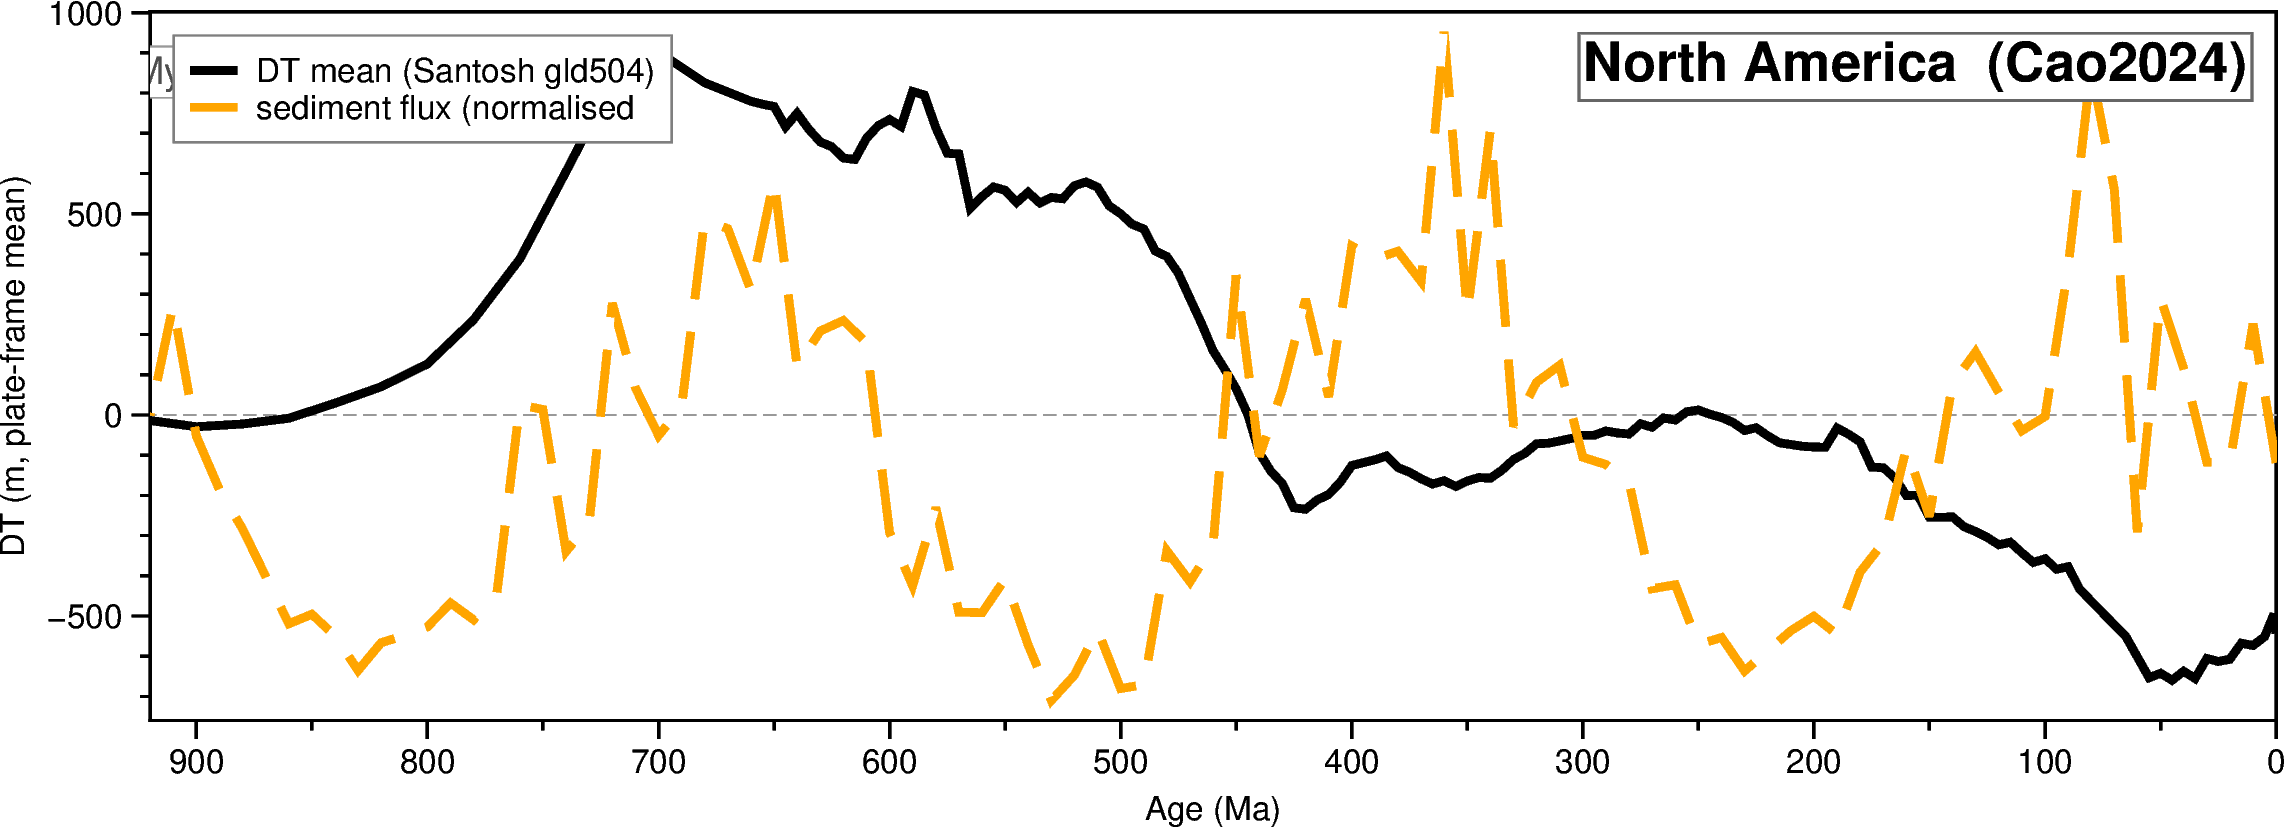

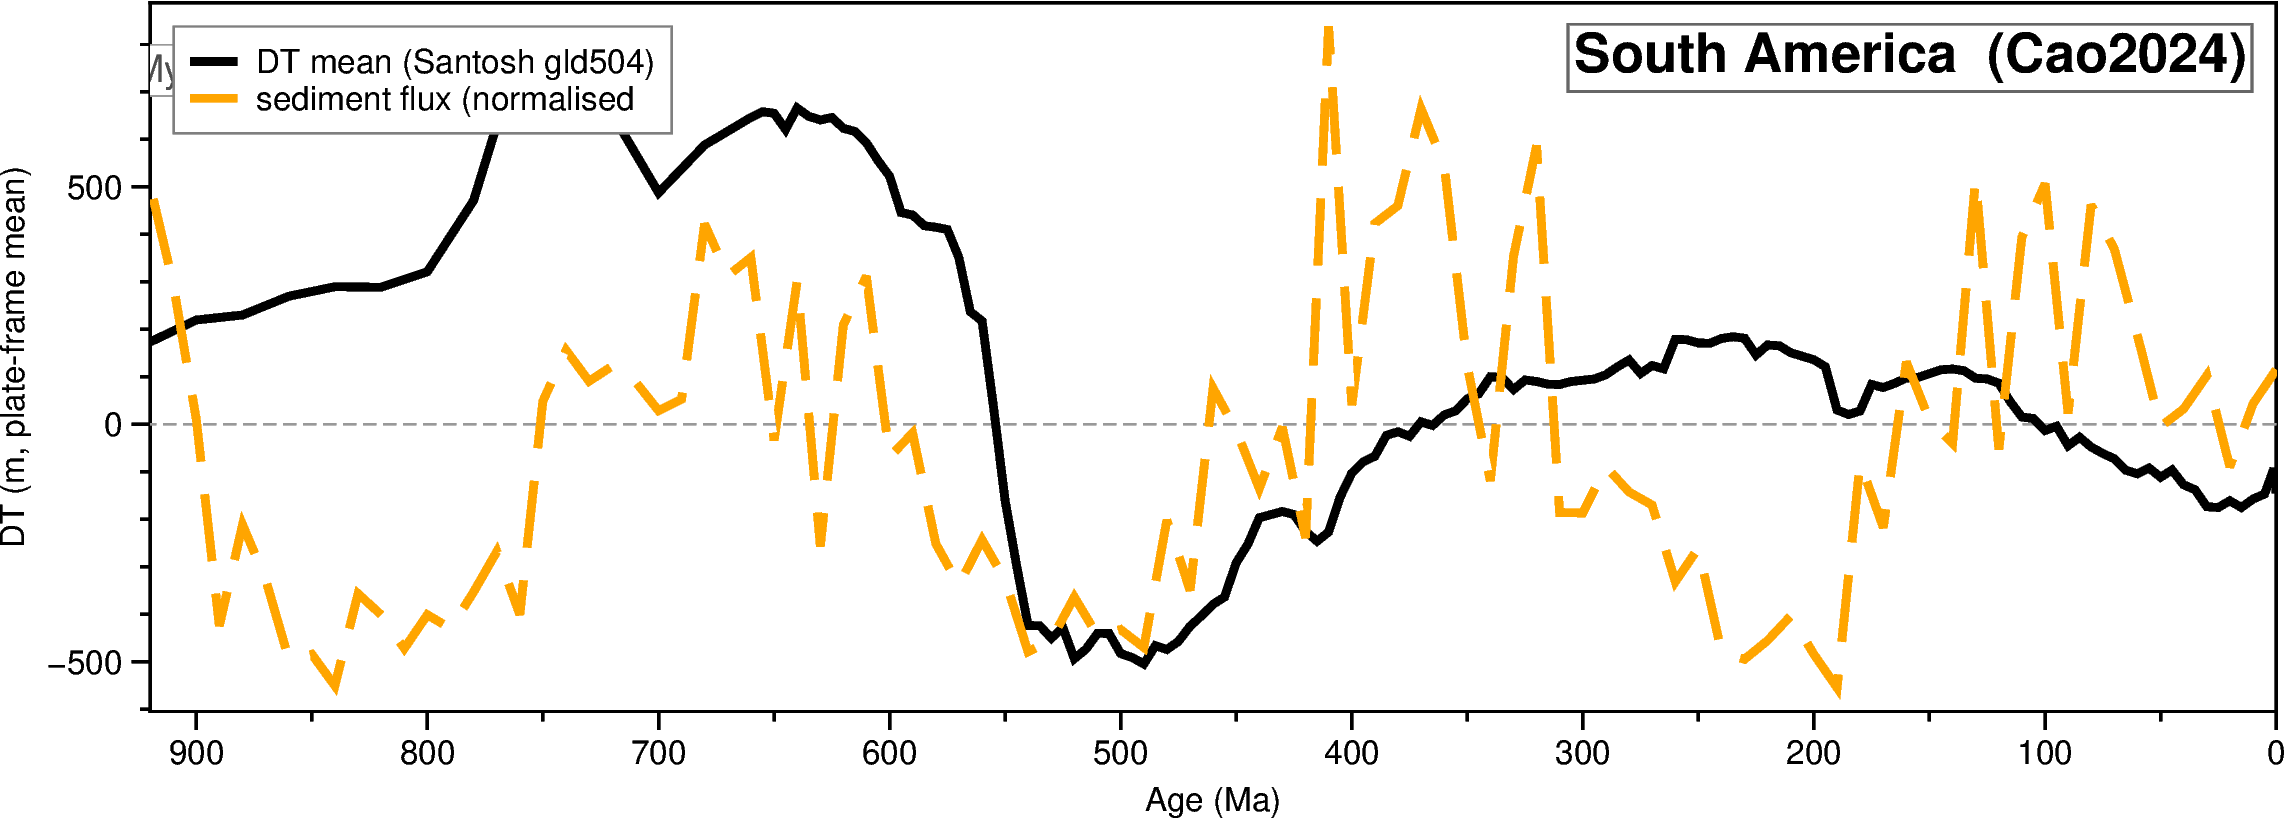

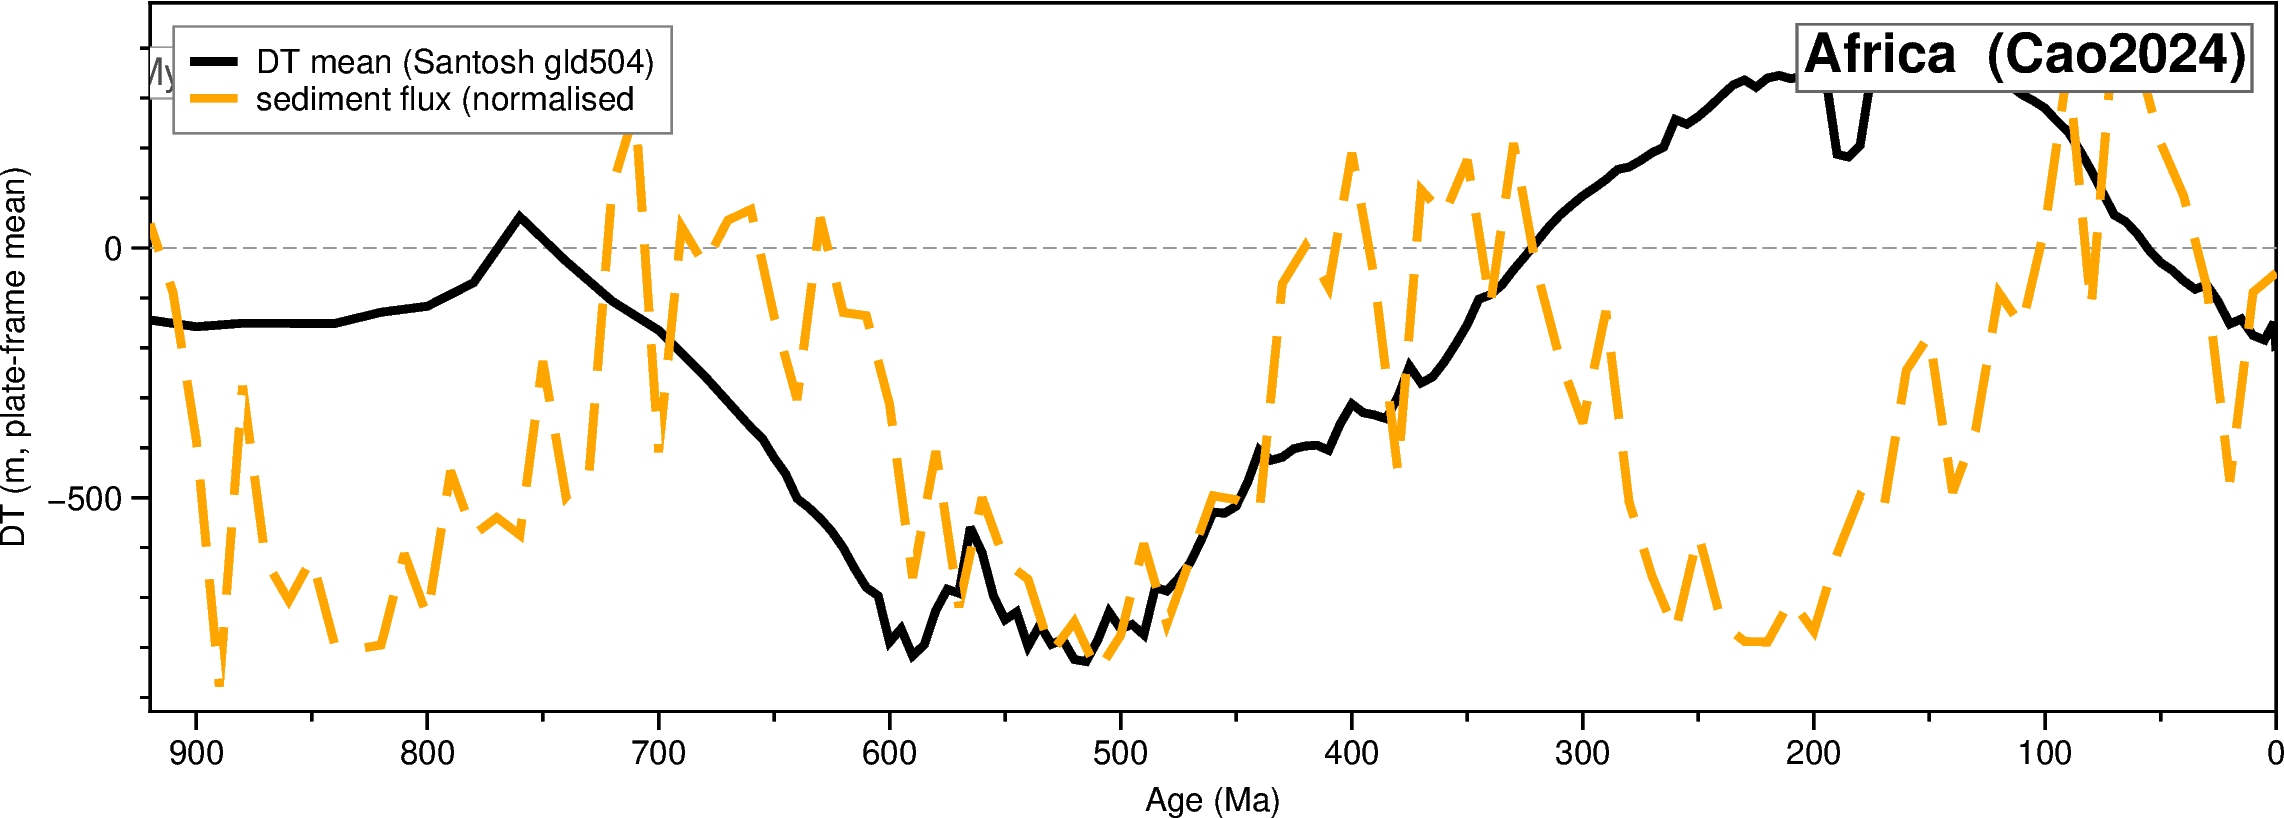

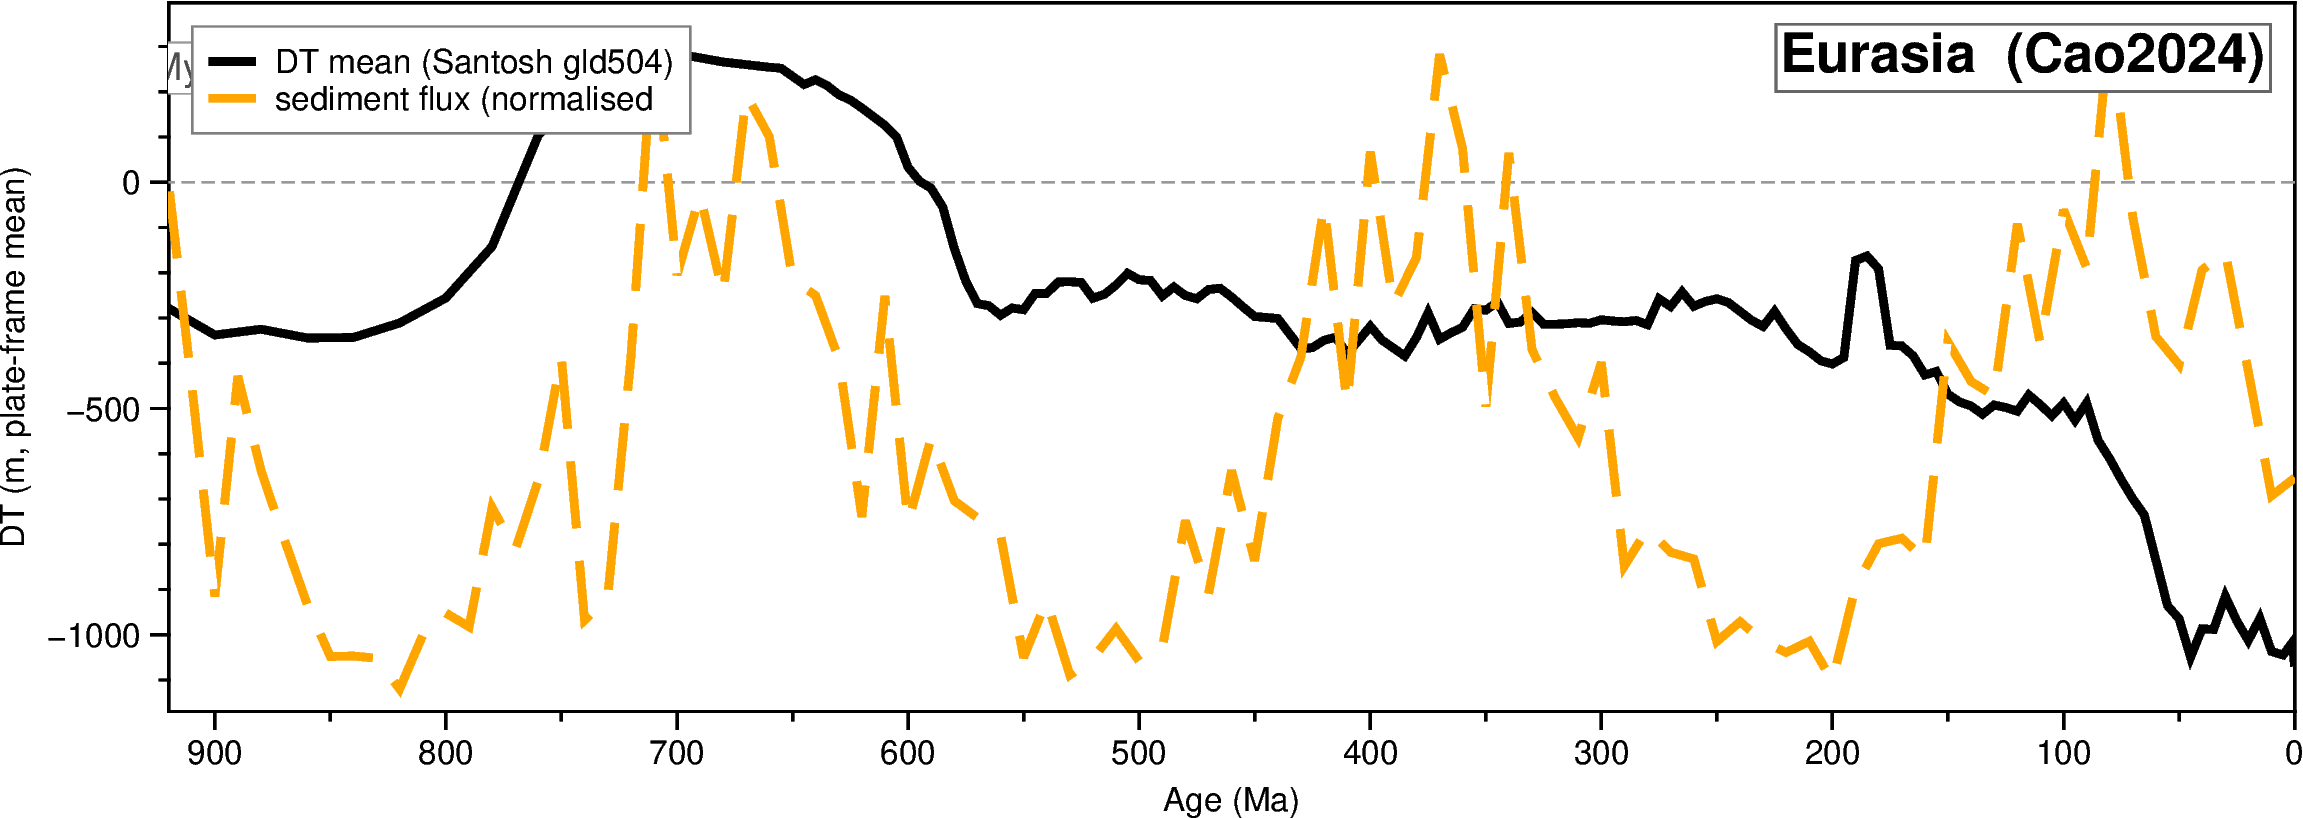

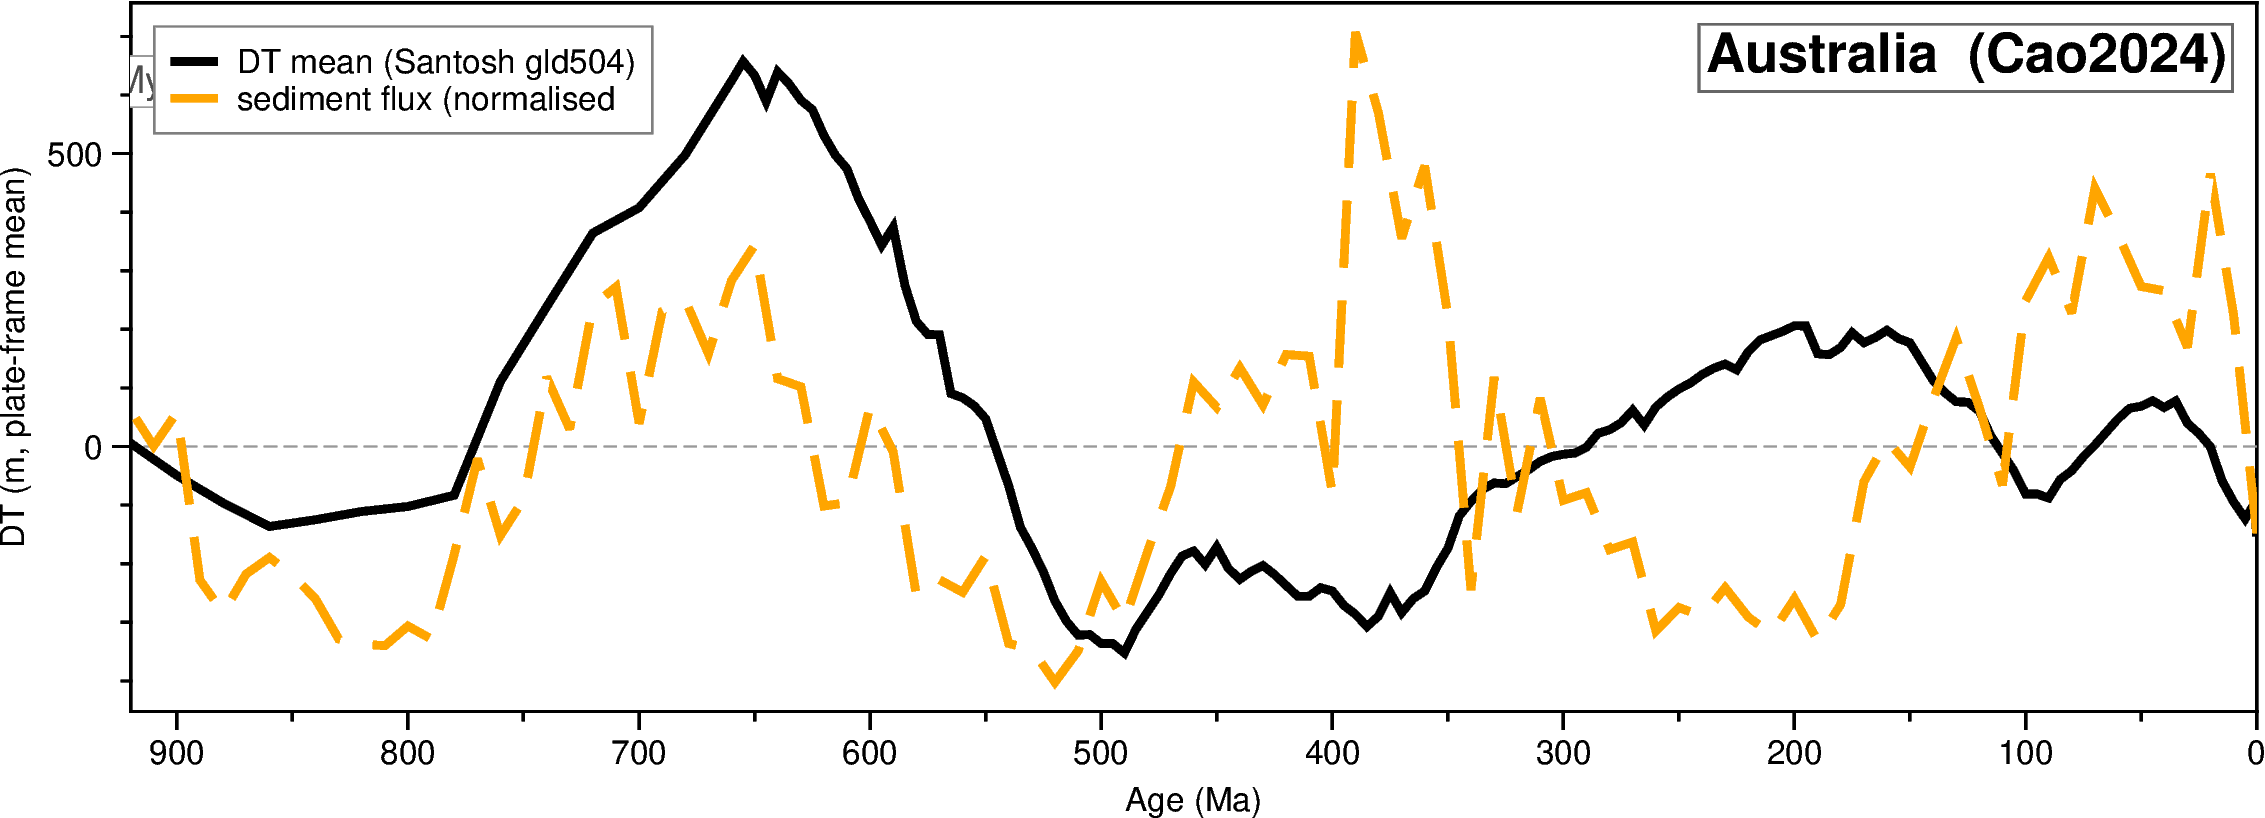

In [5]:
# Cell 4 — per-continent comparison: DT (black) vs sediment flux (orange)
# One figure per continent (suite house style — no pygmt.subplot).
# Each figure shares the same x range (0-920 Ma) so a vertical line
# at any age compares all continents at once.
X_MIN, X_MAX = 0.0, 920.0

for name in CONTINENTS:
    times_dt, mean_dt = histories[name]
    sed_hist = sed[sed["continent"] == name].sort_values("age")

    # y-range for the DT axis based on this continent's actual range
    dt_lo = float(np.nanmin(mean_dt)) - 100
    dt_hi = float(np.nanmax(mean_dt)) + 100

    fig = pygmt.Figure()
    fig.basemap(region=[X_MIN, X_MAX, dt_lo, dt_hi],
                projection="X-18c/6c",
                frame=["xa100f50+lAge (Ma)",
                       "yaf+lDT (m, plate-frame mean)", "WSrt"])
    # Reference zero line
    fig.plot(x=[X_MIN, X_MAX], y=[0, 0], pen="0.4p,gray60,--")
    # DT history in black
    fig.plot(x=times_dt, y=mean_dt, pen="2p,black",
             label=f"DT mean (Santosh {GLD_ID})")

    # Sediment flux — overplot with its own y-range using basemap2 trick:
    # we just plot scaled values on the same axis using a secondary
    # transform. For tutorial readability we keep it simple and plot
    # sed_flux normalised by its own max scaled to the DT range.
    if len(sed_hist) > 0:
        sf = sed_hist["flux_km3_per_Myr"].values
        sf_norm_to_dt = (sf - sf.min()) / max(1e-9, (sf.max() - sf.min()))
        sf_y_on_dt_axis = dt_lo + 50 + sf_norm_to_dt * (dt_hi - dt_lo - 100)
        fig.plot(x=sed_hist["age"].values, y=sf_y_on_dt_axis,
                 pen="2p,orange,-",
                 label=f"sediment flux (normalised, Ronov/Hay)")
        fig.text(text=f"sed flux: {sf.min():.0f}-{sf.max():.0f} km@+3@+/Myr",
                 x=X_MAX - 20, y=dt_hi - 100,
                 justify="TR", font="9p,Helvetica,gray30",
                 fill="white", pen="0.3p,gray60")

    fig.legend(position="JTL+jTL+o0.2c", box="+gwhite+p0.5p,gray50")
    fig.text(text=f"{name}  ({MODEL_NAME})",
             position="TR", offset="-0.25c/-0.25c", justify="TR",
             font="13p,Helvetica-Bold,black",
             fill="white", pen="0.6p,gray40")
    fig.show(width=1000)
    display(HTML('<div style="height:0.6cm"></div>'))


## What the figure shows

A per-continent panel grid of preserved-sediment-flux time series from 0 to 250 Ma. Each panel is one continent; the y-axis is sediment flux in km³ per Myr; the x-axis is age in Ma (today on the left, deep past on the right). The continent name is annotated in each panel's upper-right corner.

Look for:

- **Flux peaks aligned across panels** — peaks at similar ages across multiple continents suggest a global driver (e.g., a sea-level fall, a global tectonic event).
- **Peaks isolated to one continent** — point to regional drivers (orogenic events, regional climate shifts, dynamic topography changes).
- **Persistent low flux on one continent** — typical of stable cratons (low erosion rate, preserved-sediment volume scales with relief).

The point of the comparison with T19/T20's dynamic-topography fields is that if DT drives subsidence and erosion, the per-continent flux peaks should align in time with periods of high regional DT — a hypothesis the user can test directly by overlaying the matching DT time series for each continent on top.


## Extend this

- **Cross-correlate.** Compute lagged correlation between the DT and sediment-flux time series per continent and look for systematic continent-specific lags.
- **Other DT models.** Swap `the PlateFrameGrid_<CONTINENT>/ subdirectories scanned by the loader` for a different mantle-flow simulation and see whether the DT-sediment co-variation is robust to model choice.
- **Cross-reference T19.** T19 shows the *vertical* mantle structure under a transect; T21 shows the *horizontal* time-series at a continent. Together they make the case for the deep-mantle origin of long-term surface signals.

## References

- Dhungana, S. & Flament, N. (2025). The deep Earth origin of the Great Unconformity. *JGR — Solid Earth* (in press).
- Ronov, A.B. (1994). Phanerozoic transgressions and regressions on the continents. *American Journal of Science* 294, 777–801.
- Hay, W.W. et al. (1988). Mass/age distribution and composition of sediments on the ocean floor and the global rate of subduction. *J. Geophys. Res.* 93, 14933–14940.
- Mather, B.R., Müller, R.D., Zahirovic, S., Cannon, J., Chin, M., Ilano, L., Wright, N.M., Alfonso, C., Williams, S., Tetley, M. & Merdith, A. (2024). Deep time spatio-temporal data analysis using GPlately. *Geoscience Data Journal* 11(1), 3–10. https://doi.org/10.1002/gdj3.185
- Tian, D., Uieda, L., Leong, W.J., Fröhlich, Y., Schlitzer, W., Grund, M., Jones, M., Toney, L., Yao, J., Magen, Y., Tong, J.-H., Ngo, L., Materna, K., Belem, A., Newton, T., Anant, A., Ziebarth, M., Quinn, J. & Wessel, P. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.10578540
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochemistry, Geophysics, Geosystems* 20(11), 5556–5564. https://doi.org/10.1029/2019GC008515

- Cao, X., Collins, A.S., Pisarevsky, S., Flament, N., Li, S., Hasterok, D. & Müller, R.D. (2024). A deep-time Phanerozoic to Proterozoic plate motion model. *Earth System Science Data* 16, 4007–4032. https://doi.org/10.5194/essd-16-4007-2024
